## Rete neurale per i pinguini

fare una rete neurale che capisce di che specie è un pinguino

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder #Trasforma feature qualitative in feature quantitative
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier #Multi layer Perceptron

In [2]:
data = pd.read_csv("./penguins_size.csv")
data.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
data.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [5]:
data['island'].value_counts() #Abbiamo 3 isole: ['Biscoe', 'Dream', 'Torgersen']

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [6]:
data['species'].value_counts() #Abbiamo 3 specie

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

## Mi sistemo i dati prima di tutto

Elimino la colonna sesso, irrilevante e tolgo le righe nan

In [7]:
#Mi prendo solo queste colonne
cols = ['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g']

In [8]:
#Elimino le righe nan
pinguini_selezionati = data[cols].dropna()

In [9]:
pinguini_selezionati.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
dtypes: float64(4), object(2)
memory usage: 18.7+ KB


In [10]:
pinguini_selezionati.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0


In [11]:
island_label_encoder = LabelEncoder()
pinguini_selezionati['island_numeric'] = island_label_encoder.fit_transform(pinguini_selezionati['island'])

species_label_encoder = LabelEncoder()
pinguini_selezionati['species_numeric'] = species_label_encoder.fit_transform(pinguini_selezionati['species'])

In [12]:
pinguini_selezionati

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_numeric,species_numeric
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,2,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,2,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,2,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,2,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,2,0
...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,0,2
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,0,2
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,0,2
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,0,2


## Parte di machine learning

In [13]:
output = ['species_numeric']
features = ['island_numeric', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g']
pinguini_selezionati[features]

,island_numeric,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,2,39.1,18.7,181.0,3750.0
1,2,39.5,17.4,186.0,3800.0
2,2,40.3,18.0,195.0,3250.0
4,2,36.7,19.3,193.0,3450.0
5,2,39.3,20.6,190.0,3650.0
...,...,...,...,...,...
338,0,47.2,13.7,214.0,4925.0
340,0,46.8,14.3,215.0,4850.0
341,0,50.4,15.7,222.0,5750.0
342,0,45.2,14.8,212.0,5200.0


In [14]:
X = pinguini_selezionati[features].to_numpy()
y = pinguini_selezionati[output].to_numpy()

In [15]:
scaler = StandardScaler()
#Mi normalizza tutto!
X_norm = scaler.fit_transform(X)

## Creiamo la rete neurale

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, random_state=42, test_size=0.3)

In [17]:
neural_network = MLPClassifier(hidden_layer_sizes=(4,3), max_iter=1000)

In [18]:
neural_network.fit(X_train, y_train.reshape(-1))

,hidden_layer_sizes,"(4, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,None


In [19]:
neural_network.score(X_test, y_test) #Ha il 100% dell'accuratezza

0.8252427184466019

In [20]:
features

['island_numeric',
 'culmen_length_mm',
 'culmen_depth_mm',
 'flipper_length_mm',
 'body_mass_g']

In [21]:
penguindoe = np.array([[0, 40, 30, 190, 5000]])

In [22]:
penguindoe_norm = scaler.transform(penguindoe)

In [23]:
neural_network.predict(penguindoe_norm)

array([0])

In [136]:
from joblib import dump 
#Il file contiene la rete neurale addestrata con tutti i suoi metodi
dump(neural_network, 'rete_neurale_pinguini.dump')

['rete_neurale_pinguini.dump']

In [49]:
def disegnaGrafico(x_name, y_name, data, cat_name, ax):
    lista = data[cat_name].unique()
    if x_name == y_name:
        for elemento in lista:
            selected_data = data[data[cat_name]== elemento]
            ax.hist(selected_data[x_name], alpha = 0.5, bins = 15, label=elemento)
            ax.set_xlabel(x_name)
            ax.set_ylabel("Numero di casi")
    else:
        for elemento in lista:
            selected_data = data[data[cat_name]== elemento]
            ax.scatter(selected_data[x_name], selected_data[y_name], alpha = 0.5, label=elemento)
            ax.set_xlabel(x_name)
            ax.set_ylabel(y_name)
    ax.legend(labels = ["Biscoe", "Dream", "Torgersen"])
    ax.grid()

In [65]:
def analisiGrafica(data, cat_name):
    nomi_colonne = [col for col in data.columns if col != cat_name]
    
    n_vars = len(nomi_colonne)
    fig, axs = plt.subplots(nrows=n_vars, ncols=n_vars, figsize=(30, 30))
    
    for i, var1 in enumerate(nomi_colonne):
        for j, var2 in enumerate(nomi_colonne):
            disegnaGrafico(var1, var2, data, cat_name, axs[i, j])

    plt.savefig("pinguini.pdf")
    plt.show()

In [66]:
selected_cols = features + output
selected_cols

['island_numeric',
 'culmen_length_mm',
 'culmen_depth_mm',
 'flipper_length_mm',
 'body_mass_g',
 'species_numeric']

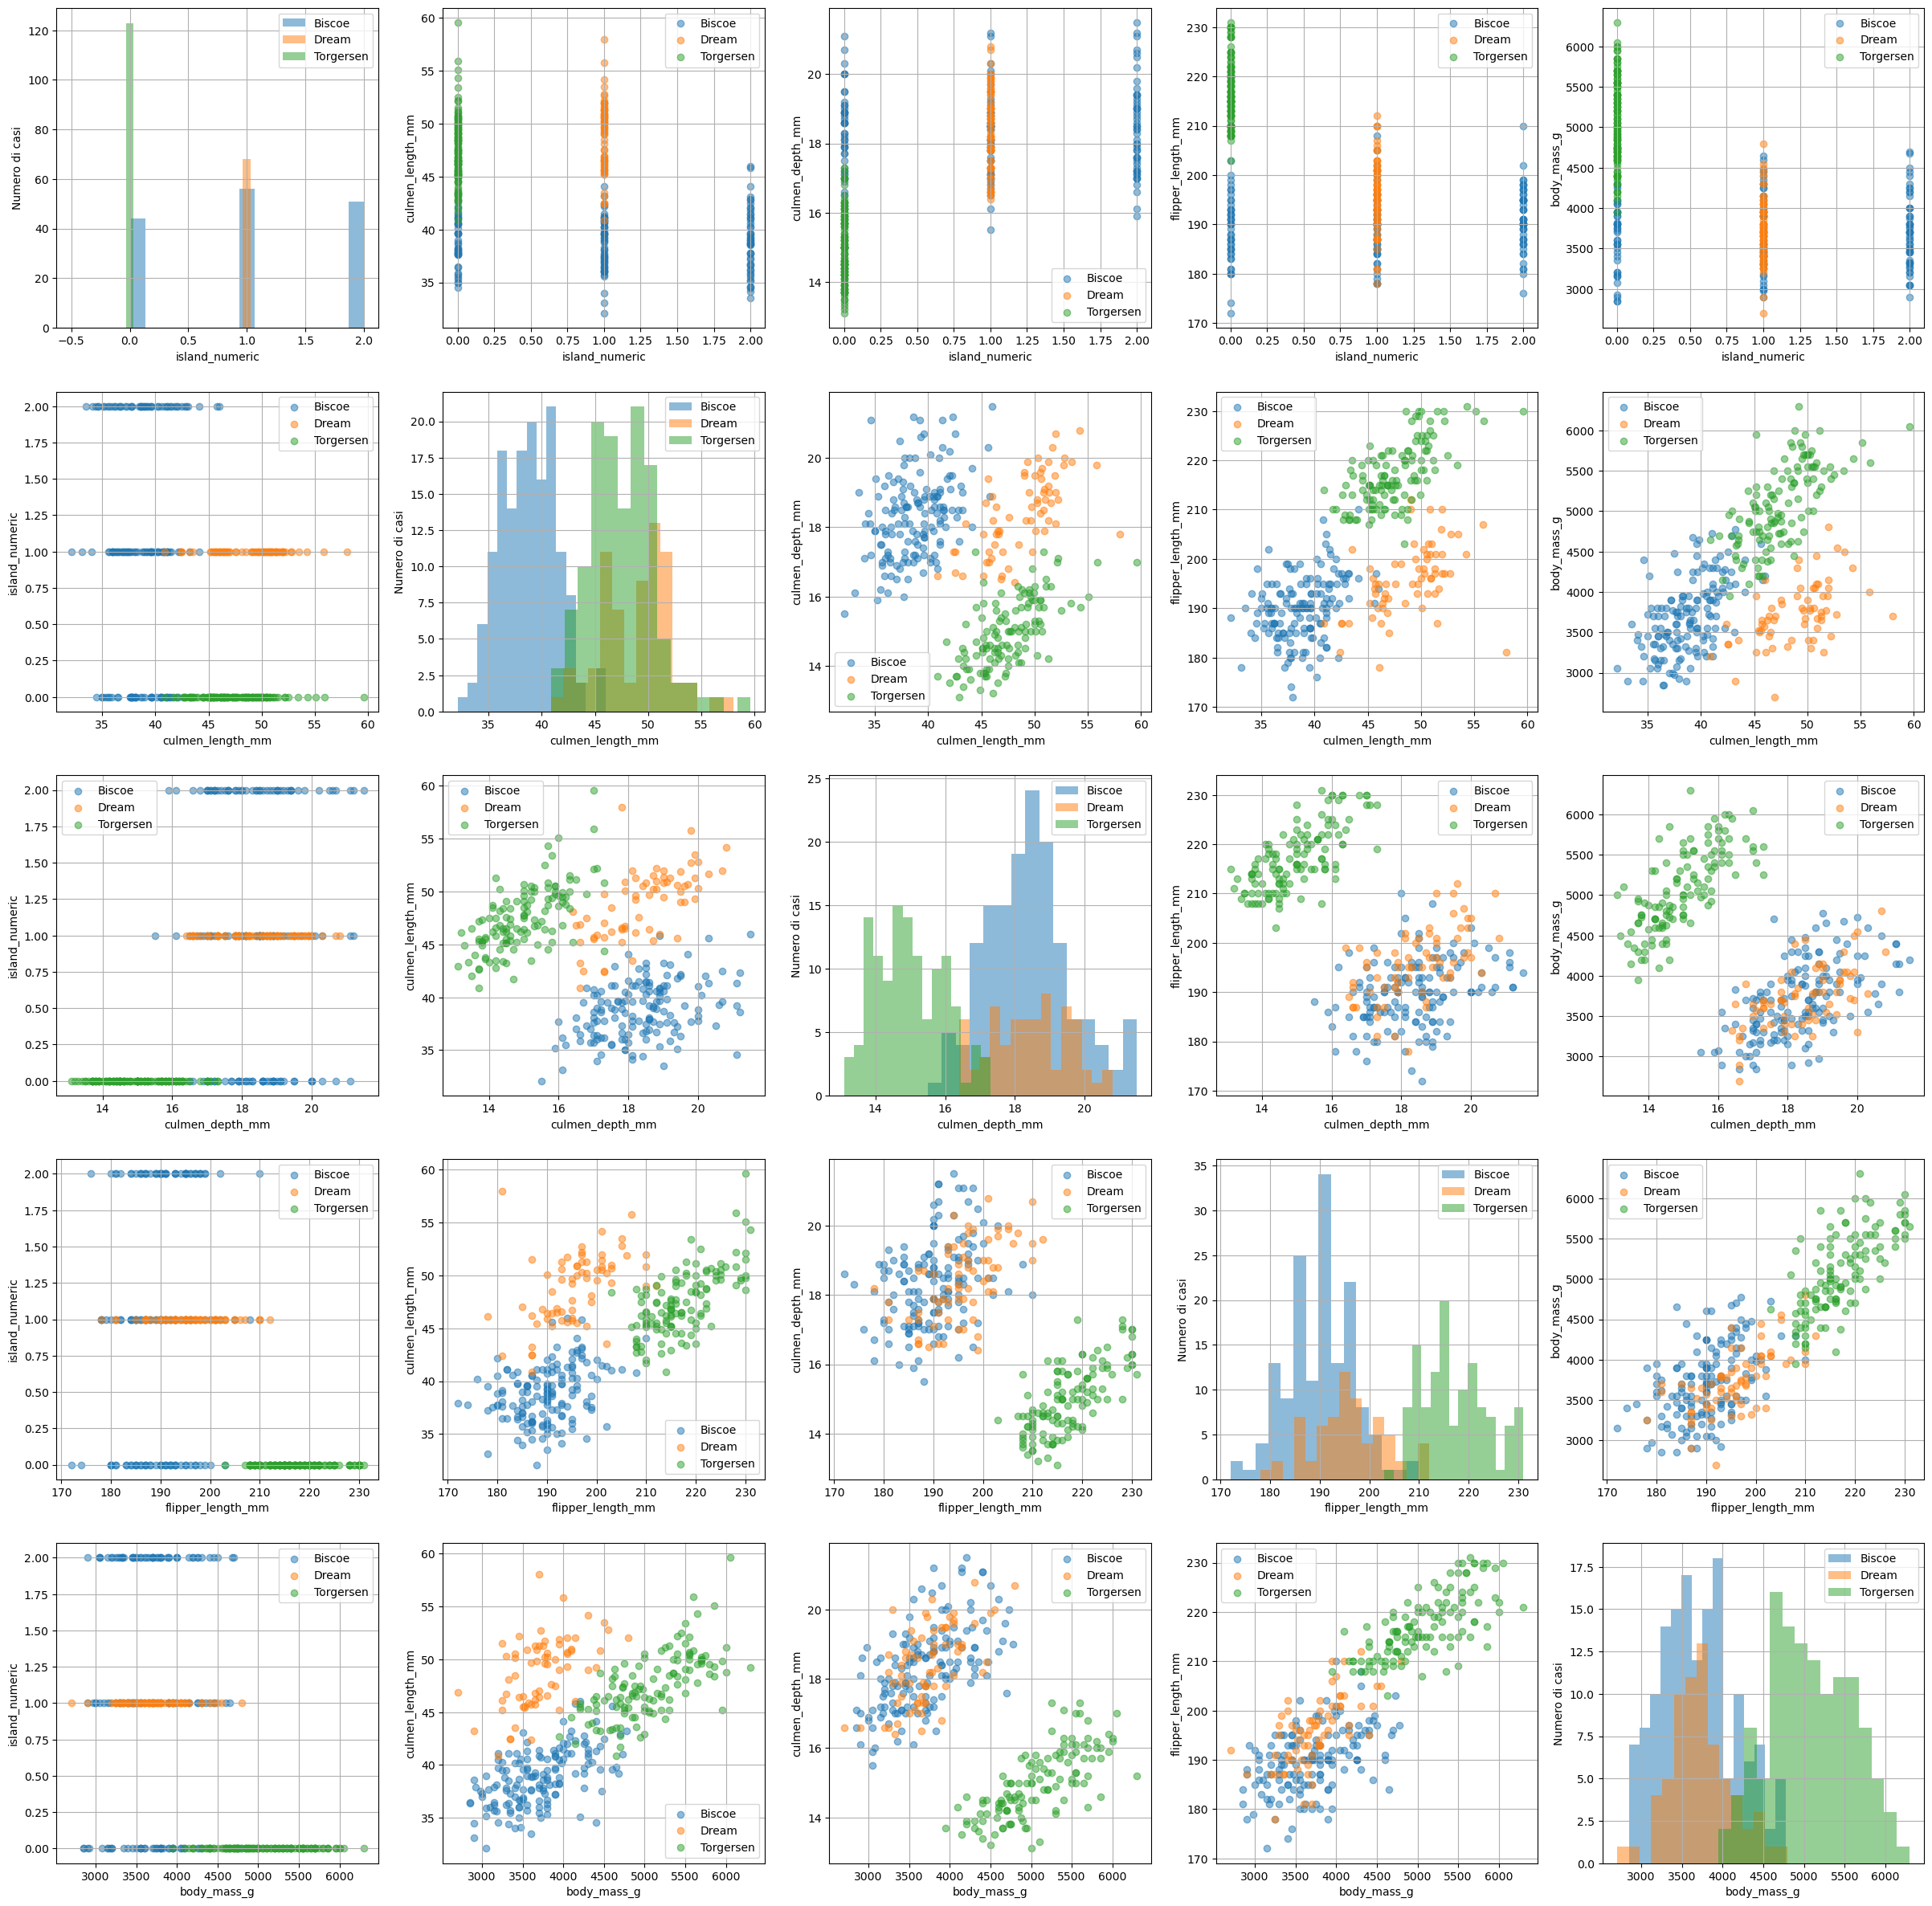

In [67]:
analisiGrafica(pinguini_selezionati[selected_cols], 'species_numeric')

In [57]:
pinguini_selezionati

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_numeric,species_numeric
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,2,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,2,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,2,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,2,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,2,0
...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,0,2
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,0,2
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,0,2
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,0,2
